<img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
     align="center"
     width="400"/>

# ANALITICA BASADA EN ARBOLES DE CLASIFICACION Y REGRESION

## *Proyecto Final*

Los roles que deben cumplir son:



* Data Engineer  -   Limpieza y preparación
* Data Analyst   -  EDA y visualizaciones
* ML Engineer  -  Entrenamiento de modelos
* Research Lead  -  Interpretación y documentación

* ¿Qué variables impactan más el desempeño?
* ¿Influye el consumo de alcohol?
* ¿Influye el nivel educativo de los padres?
* ¿Las ausencias afectan significativamente?
* ¿Existen diferencias entre estudiantes urbanos y rurales?
* ¿Qué tan predictivas son G1 y G2 para G3?

Modelos a ensayar (tip lean el paper, principalmente el grupo research lead/ML engineer):
1. Regresión lineal (Humberto) ✅
2. Árboles de decisión (Cynthia) ✅
3. Random Forest (DiegoF) ✅
4. Logistic Regression (Alexa) ✅
5. XGBoost (Monica) ✅
6. LightGBM (Acoyani) ✅
7. CatBoost (Guillermo) ✅
8. Stacking (Joel) ✅

Mínimos exigibles:
Al menos 7 visualizaciones
Comparación de mínimo 6 modelos
Métricas y explicación de por qué si o por qué no:
* Accuracy
* RMSE o MAE
* F1-score (si clasifican)
* Validación cruzada
* Feature importance

# INTRODUCCION
Como parte de este proyecto vamos a utilizar el dataset de [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance), utilizando solo una clase ya sea Matematicas o Portugues.

Vamos a seguir mayormente los pasos que se usaron en el Paper [USING DATA MINING TO PREDICT SECONDARY SCHOOL STUDENT PERFORMANCE](https://repositorium.uminho.pt/server/api/core/bitstreams/991a0e2b-249d-466d-afef-937d975ff7fc/content), utilizando el modelo Random Forest para hacer la predicción.

## EDA

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Leer el dataset (solo portugués)
df = pd.read_csv('student-por.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## Definir variable objetivo de calificacion en sus distintas formas

In [4]:
# Formato binario
df['target_binary'] = (df['G3'] >= 10).astype(int)

# Formato de calificación a 5 niveles (I-V -> 1-5)
def grade_to_levels(col):
    if col >= 16:
        return 1  # I
    elif col >= 14:
        return 2  # II
    elif col >= 12:
        return 3  # III
    elif col >= 10:
        return 4  # IV
    else:
        return 5  # V (fail)

df['target_levels'] = df['G3'].apply(grade_to_levels)

# Directamente G3
df['target'] = df['G3'].astype(float)

# Display
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,target_binary,target_levels,target
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,4,0,11,11,1,4,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,1,3,2,9,11,11,1,4,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,3,3,6,12,13,12,1,3,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,1,5,0,14,14,14,1,2,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,1,2,5,0,11,13,13,1,3,13.0


## Definir los setups segun el paper


* Setup A: todas las columnas excepto G3 y targets.
* Setup B: como A pero sin G2.
* Setup C: como B pero sin G1 (no hay G1 ni G2).



In [5]:
# Excluir variable objetivo
target_cols = ['G3', 'target_binary', 'target_levels', 'target']

# Setup A - Todas menos target
setup_A = [col for col in df.columns if col not in target_cols]

# Setup B - Sin G2
setup_B = [col for col in setup_A if col != 'G2']

# Setup C - Sin G1
setup_C = [col for col in setup_B if col != 'G1']

setups = {
    'A': setup_A,
    'B': setup_B,
    'C': setup_C
}

print(f"Setup: A - Columnas: {setup_A}")
print(f"Setup: B - Columnas: {setup_B}")
print(f"Setup: C - Columnas: {setup_C}")

Setup: A - Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Setup: B - Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1']
Setup: C - Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', '

## Transformar variables categoricas
Usaremos one-hot para las categoricas y las numericas quedan tal cual.

In [6]:
# Identificar variables categoricas vs numericas
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
numerical_cols = [col for col in df.columns if col not in categorical_cols]
print(f'Categorical columns: {categorical_cols}')
print(f'Numerical columns: {numerical_cols}')

Categorical columns: []
Numerical columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'target_binary', 'target_levels', 'target']


## Correlacion
Obtenemos mapa de correlación con las variables numericas

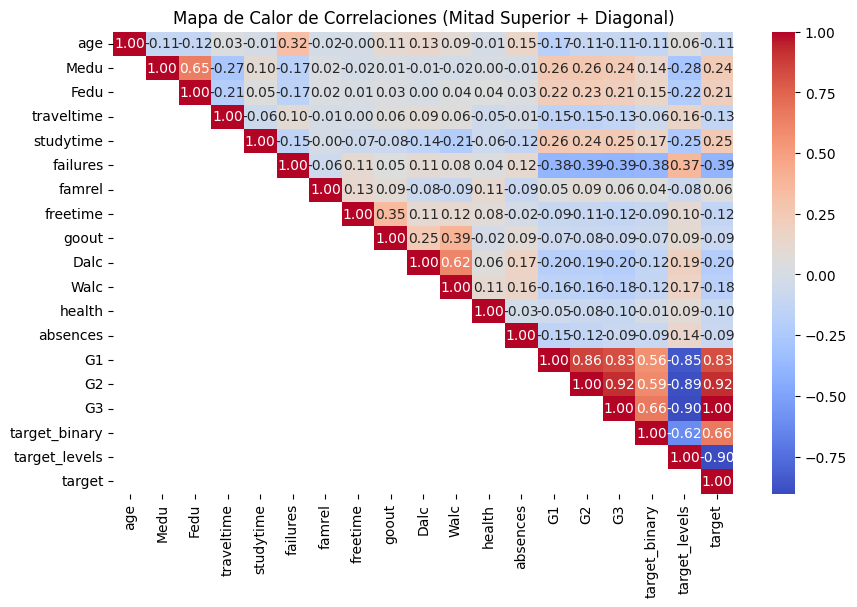

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df[numerical_cols].select_dtypes(include=['number']).columns.tolist()
corr = df[numerical_cols].corr()

# Mantiene diagonal + mitad superior
mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Mapa de Calor de Correlaciones (Mitad Superior + Diagonal)')
plt.show()

## Definicion de preprocesamiento (General)

Aquí se define que transformaciones se aplican a las variables numéricas y categóricas que se pueden utilizar en todos los modelos.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def make_generic_preprocessor(feature_cols):
  cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
  num_cols = [c for c in feature_cols if c not in cat_cols]

  # Definimos las transformaciones para variables numéricas
  num_pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()) # Agregamos el escalador segun el modelo es la escala
  ])

  # Definimos las transformaciones para variables categóricas
  cat_pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="most_frequent")),
      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
  ])

  # Unimos ambos en el ColumnTransformer
  preprocessor = ColumnTransformer(
      transformers=[
          ("num", num_pipeline, num_cols),
          ("cat", cat_pipeline, cat_cols)
      ]
  )

  return preprocessor

## Declaracion de CV e intervalos de confianza

In [9]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import scipy.stats as stats

def mean_ci_95(values):
    """
    Devuelve (mean, lower, upper) para un intervalo de confianza del 95%
    usando t de Student.
    """
    values = np.array(values)
    n = len(values)
    mean = values.mean()
    if n < 2:
        return mean, mean, mean
    se = stats.sem(values)  # error estándar
    h = se * stats.t.ppf(0.975, n - 1)  # half-width IC
    return mean, mean - h, mean + h

def repeated_cv_classification(
    X, y, model, n_runs=20, n_splits=10, random_state_base=42
):
    scores = []
    n_samples = len(y)
    for run in range(n_runs):
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=random_state_base + run
        )
        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            scores.append(acc)
    return scores

def repeated_cv_regression(
    X, y, model, n_runs=20, n_splits=10, random_state_base=42
):
    scores = []
    n_samples = len(y)
    for run in range(n_runs):
        kf = KFold(
            n_splits=n_splits, shuffle=True, random_state=random_state_base + run
        )
        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = mean_squared_error(y_test, y_pred)
            scores.append(rmse)
    return scores

## Como usar el preprocesamiento y las funciones genericas en los modelos?

In [10]:
# Ejemplo como usar mismo preprocessor y pipeline con Random Forest Classifier

# Guardar resultados para hacer comparativa
results = {}

# Por cada setup (A, B, C):
for setup_name, feature_cols in setups.items():

  # Loggear que estamos haciendo en cada paso
  print(f"\n=== Random Forest con Binary Classification, setup {setup_name} ===")

  # Se define el preprocessor -- Las transformaciones
  example_preprocessor = make_generic_preprocessor(feature_cols)

  # Se define el pipeline (el modelo con las transformaciones)
  example_pipeline = Pipeline([
      ("preprocessor", example_preprocessor),
      ("classifier", RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)) # <<< Tu modelo va aqui
  ])


  # Correr con todas las variables
  X = df[feature_cols]

  # Correr con variable objetivo binaria
  # Recordar que existen las variables:
  # 1. target_levels del rango 1-5 -- Escala de I-V
  # 2. target_binary en el rango [0,1] -- Aprueba o no aprueba
  # 3. target con la escala original -- Del 0 al 19
  y_binary = df['target_binary']

  # Recalcular tipos usando X para evitar que columnas string caigan en el pipeline numérico
  cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
  num_cols = X.select_dtypes(include=['number']).columns.tolist()

  # Rehacer preprocesador/pipeline con columnas correctas
  example_preprocessor = ColumnTransformer(
        transformers=[
              ("num", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
              ]), num_cols),
              ("cat", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
              ]), cat_cols)
        ]
  )

  example_pipeline = Pipeline([
        ("preprocessor", example_preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1))
  ])

  scores = repeated_cv_classification(X, y_binary, example_pipeline, n_runs=3, n_splits=5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  # Guardar resultados para hacer comparativa

  results[setup_name] = (mean_acc, ci_low, ci_high)

  # Obtener las metricas correspondientes al modelo ejecutado y generar algunas conclusiones
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")



=== Random Forest con Binary Classification, setup A ===
Accuracy: 0.9255 (95% CI: [0.9190, 0.9320])

=== Random Forest con Binary Classification, setup B ===
Accuracy: 0.9039 (95% CI: [0.8952, 0.9127])

=== Random Forest con Binary Classification, setup C ===
Accuracy: 0.8510 (95% CI: [0.8428, 0.8593])


In [11]:
## Usar estas funciones como auxiliares para la comparación de resultados e importancias de features
def results_to_df(results_dict, task_name):
    rows = []
    for setup, (mean_val, ci_low, ci_high) in results_dict.items():
        rows.append({
            "setup": setup,
            "task": task_name,
            "mean": mean_val,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "ci_err": (ci_high - ci_low) / 2.0
        })
    return pd.DataFrame(rows)

def importances_to_df(importances_dict, task_name):
    rows = []
    for setup, importances in importances_dict.items():
        for importance in importances:
            rows.append({
                "setup": setup,
                "task": task_name,
                "feature": importance['feature'],
                "importance": importance['importance']
            })
    return pd.DataFrame(rows)

from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

def get_pipeline_importances_generic(
    pipeline,
    X,
    preprocessor_name='preprocessor',
    model_name='classifier',
    coef_aggregation='l2'
):

    preprocessor = pipeline.named_steps[preprocessor_name]
    model = pipeline.named_steps[model_name]

    feature_names = []

    if isinstance(preprocessor, ColumnTransformer):
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == 'drop':
                continue
            if transformer == 'passthrough':
                feature_names.extend(cols)
            else:
                if hasattr(transformer, 'get_feature_names_out'):
                    try:
                        fn = transformer.get_feature_names_out(cols)
                    except TypeError:
                        fn = transformer.get_feature_names_out()
                    feature_names.extend(fn)
                else:
                    feature_names.extend(cols)
    else:
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = X.columns

    feature_names = np.array(feature_names)

    # Obtenemos importancias
    if hasattr(model, 'feature_importances_'):
        # Modelos tipo árbol
        importances = model.feature_importances_

    elif hasattr(model, 'coef_'):
        # Modelos lineales
        coefs = model.coef_

        # coefs puede ser:
        # - 1D (n_features,) en regresión simple
        # - 2D (n_clases, n_features) en clasificación multiclase
        coefs = np.atleast_2d(coefs)  # fuerza 2D para unificar lógica

        if coef_aggregation == 'l2':
            importances = np.linalg.norm(coefs, axis=0)
        elif coef_aggregation == 'mean_abs':
            importances = np.mean(np.abs(coefs), axis=0)
        else:
            raise ValueError(f"coef_aggregation '{coef_aggregation}' no reconocido")
    else:
        raise AttributeError(
            "El modelo final no tiene ni 'feature_importances_' ni 'coef_'. "
            "No se puede calcular importancia de features."
        )

    # Checar que haya match
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Longitud de importances ({len(importances)}) != longitud de feature_names ({len(feature_names)})."
        )

    # Hacer DataFrame y devolver como lista de dicts
    df_imp = (
        pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })
        .sort_values('importance', ascending=False)
    )

    return df_imp.to_dict(orient='records')

## Random Forest

### Definición de modelo Random Forest y preprocesamiento

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


def make_rf_pipeline(feature_cols, df, task="classification"):
    # Separar categoricas y numericas como lo hicimos anteriormente
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat",
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("onehot", OneHotEncoder(handle_unknown="ignore"))
             ]),
             cat_cols),
            ("num",
             SimpleImputer(strategy="median"),
             num_cols)
        ]
    )

    if task == "classification":
        rf = RandomForestClassifier(
            n_estimators=500,
            random_state=0,
            n_jobs=-1
        )
    else:
        rf = RandomForestRegressor(
            n_estimators=500,
            random_state=0,
            n_jobs=-1
        )

    return Pipeline([
        ("preprocess", preprocessor),
        ("rf", rf)
    ])

### Correr Random Forest con los 3 setups

In [13]:
# Correr con variable de niveles
y_levels = df['target_levels']

rf_results_levels = {}
rf_importances_levels = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Levels classification, setup {setup_name} ===")
    X = df[feature_cols]

    # Ejecutar modelo
    model = make_rf_pipeline(feature_cols, df, task="classification")
    # Rehacer pipeline para evitar que columnas categóricas caigan en imputación numérica
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()

    model = Pipeline([
      ("preprocess", ColumnTransformer(
        transformers=[
          ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
          ]), cat_cols),
          ("num", SimpleImputer(strategy="median"), num_cols)
        ]
      )),
      ("rf", RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1))
    ])

    scores = repeated_cv_classification(X, y_levels, model, n_runs=3, n_splits=5)

    # Imprimir metricas
    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    rf_results_levels[setup_name] = (mean_acc, ci_low, ci_high)
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

    # Obtener importancia de variables
    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='rf')
    rf_importances_levels[setup_name] = importances


=== Levels classification, setup A ===
Accuracy: 0.7293 (95% CI: [0.7102, 0.7484])

=== Levels classification, setup B ===
Accuracy: 0.5439 (95% CI: [0.5222, 0.5657])

=== Levels classification, setup C ===
Accuracy: 0.3549 (95% CI: [0.3347, 0.3750])


In [ ]:
# Correr con variable binaria
y_binary = df['target_binary']

rf_results_binary = {}
rf_importances_binary = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Binary classification, setup {setup_name} ===")
    X = df[feature_cols]

    # Ejecutar modelo
    model = make_rf_pipeline(feature_cols, df, task="classification")
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()

    model = Pipeline([
      ("preprocess", ColumnTransformer(
        transformers=[
          ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
          ]), cat_cols),
          ("num", SimpleImputer(strategy="median"), num_cols)
        ]
      )),
      ("rf", RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1))
    ])

    scores = repeated_cv_classification(X, y_binary, model, n_runs=3, n_splits=5)

    # Imprimir metricas
    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    rf_results_binary[setup_name] = (mean_acc, ci_low, ci_high)
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

    # Obtener importancia de variables
    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='rf')
    rf_importances_binary[setup_name] = importances


=== Binary classification, setup A ===


In [ ]:
# Correr con variable objetivo con valores originales
y_direct = df['target']

rf_results_direct = {}
rf_importances_direct = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Regression, setup {setup_name} ===")
    X = df[feature_cols]

    # Ejecutar modelo
    model = make_rf_pipeline(feature_cols, df, task="regression")
    # Rehacer pipeline usando tipos reales de X (evita imputar strings con median)
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()

    model = Pipeline([
      ("preprocess", ColumnTransformer(
        transformers=[
          ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
          ]), cat_cols),
          ("num", SimpleImputer(strategy="median"), num_cols)
        ]
      )),
      ("rf", RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1))
    ])

    scores = repeated_cv_regression(X, y_direct, model, n_runs=3, n_splits=5)

    # Imprimir metricas
    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    rf_results_direct[setup_name] = (mean_acc, ci_low, ci_high)
    print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

    # Obtener importancia de variables
    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='rf')
    rf_importances_direct[setup_name] = importances


=== Regression, setup A ===


RMSE: 1.6600 (95% CI: [1.3479, 1.9721])

=== Regression, setup B ===
RMSE: 3.1470 (95% CI: [2.7369, 3.5572])

=== Regression, setup C ===
RMSE: 7.2830 (95% CI: [6.5778, 7.9883])


In [ ]:
import pandas as pd
import numpy as np

rf_df_lvl = results_to_df(rf_results_levels, task_name="levels")
rf_df_bin = results_to_df(rf_results_binary, task_name="binary")
rf_df_reg = results_to_df(rf_results_direct, task_name="regresion")

rf_df_acc = pd.concat([rf_df_bin, rf_df_lvl, rf_df_reg], ignore_index=True)
rf_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.923967,0.916889,0.931046,0.007079
1,B,binary,0.903419,0.894100,0.912738,0.009319
2,C,binary,0.848475,0.840251,0.856700,0.008225
3,A,levels,0.729306,0.710222,0.748391,0.019084
4,B,levels,0.543948,0.522177,0.565718,0.021771
5,C,levels,0.354864,0.334742,0.374986,0.020122
6,A,regresion,1.659969,1.347857,1.972081,0.312112
7,B,regresion,3.147026,2.736863,3.557189,0.410163
8,C,regresion,7.283048,6.577824,7.988273,0.705224


In [ ]:
import pandas as pd
import numpy as np

rf_df_lvl_vars = importances_to_df(rf_importances_levels, task_name='levels')
rf_df_bin_vars = importances_to_df(rf_importances_binary, task_name='binary')
rf_df_reg_vars = importances_to_df(rf_importances_direct, task_name='regresion')

rf_df_vars = pd.concat([rf_df_lvl_vars, rf_df_bin_vars, rf_df_reg_vars], ignore_index=True)
rf_df_vars

,setup,task,feature,importance
0,A,levels,G2,0.221354
1,A,levels,G1,0.134552
2,A,levels,absences,0.031998
3,A,levels,age,0.028264
4,A,levels,health,0.027787
...,...,...,...,...
508,C,regresion,Mjob_health,0.003663
509,C,regresion,guardian_other,0.003027
510,C,regresion,Fjob_health,0.002279
511,C,regresion,paid_no,0.001747


### Graficamos para comparar (Random Forest)

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_normal_from_ci(mean, ci_low, ci_high, label, color, ax):
    sigma = (ci_high - mean) / 1.96
    x = np.linspace(mean - 4*sigma, mean + 4*sigma, 300)
    y = norm.pdf(x, loc=mean, scale=sigma)
    ax.plot(x, y, color=color, label=label)
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7)
    return ax

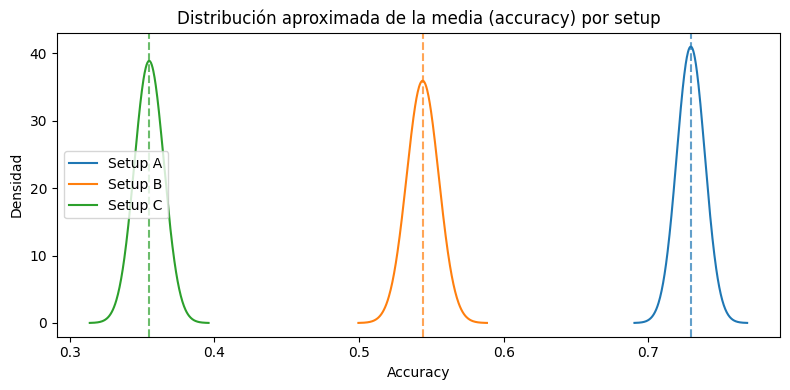

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = rf_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

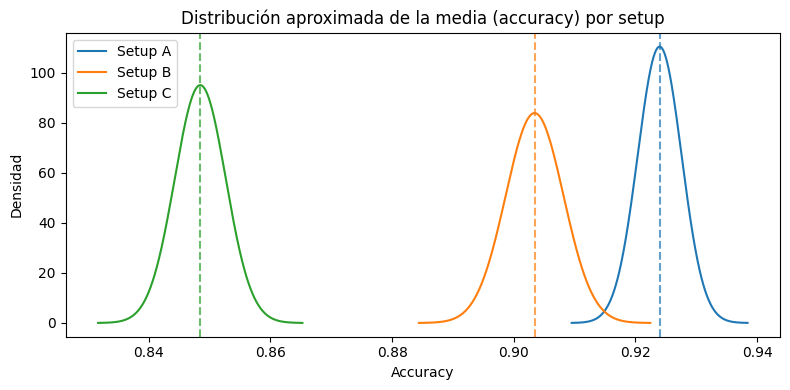

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = rf_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

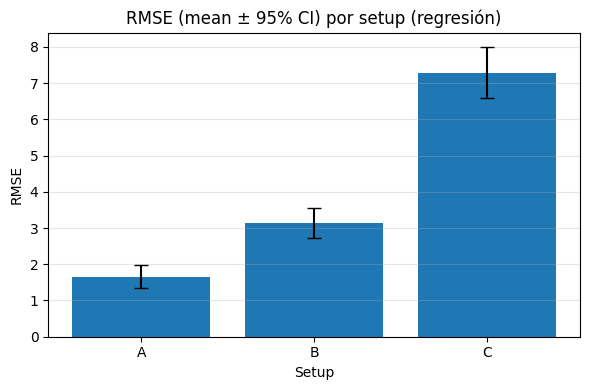

In [ ]:
df_reg = results_to_df(rf_results_direct, task_name="regression")

import matplotlib.pyplot as plt
import numpy as np

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('RMSE (mean ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones Random Forest


* Las variables (G1, G2) son los predictores más fuertes de la nota final (G3).

* Con G2 (y G1) se obtiene alta exactitud en clasificación y bajo error (RMSE) en regresión.

Sin ellas, el rendimiento cae de forma drástica.
* G2 (segunda evaluación) es más informativa que G1, especialmente para:
   * Regresión (RMSE se reduce casi a la mitad al pasar de B a A).
   * Clasificación 5 niveles (0.54 → 0.73).

Las demás variables (demográficas, sociales, escolares) sí aportan señal, pero:
Explican mucho menos que las notas previas.

Sin G1/G2, el modelo funciona pero con error alto, lo que indica que describen el rendimiento de los estudiantes, pero no capturan tan bien el score exacto.

Los resultados coinciden con lo visto en el paper:
* Mejor desempeño cuando se usan G1/G2.
* Peor cuando se eliminan.
* Diferencias claras entre setups A/B/C en todas los escenarios.


## Arboles de decisión

In [ ]:
# Modelo Arboles de Decision ---------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

dt_results_levels = {}
dt_results_binary = {}
dt_results_direct = {}

dt_importance_levels = {}
dt_importance_binary = {}
dt_importance_direct = {}

In [ ]:
# Levels

for setup_name, feature_cols in setups.items():

  print(f"\n=== Decision Tree Levels Classification, setup {setup_name} ===")

  dt_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Decision Tree
  dt_pipeline = Pipeline([
      ("preprocessor", dt_preprocessor),
      ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=0
    ))
  ])

  # Features
  X = df[feature_cols]
  y_levels = df['target_levels']

  # Rebuild preprocessing from X dtypes to avoid sending strings to median imputer
  cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
  num_cols = X.select_dtypes(include=['number']).columns.tolist()

  dt_preprocessor = ColumnTransformer(
      transformers=[
          ("num", Pipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler())
          ]), num_cols),
          ("cat", Pipeline([
              ("imputer", SimpleImputer(strategy="most_frequent")),
              ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
          ]), cat_cols)
      ]
  )

  dt_pipeline = Pipeline([
      ("preprocessor", dt_preprocessor),
      ("classifier", DecisionTreeClassifier(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      ))
  ])

  scores = repeated_cv_classification(X, y_levels, dt_pipeline, n_runs=3, n_splits=5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  dt_results_levels[setup_name] = (mean_acc, ci_low, ci_high)
  importances = get_pipeline_importances_generic(dt_pipeline, X, preprocessor_name='preprocessor', model_name='classifier')
  dt_importance_levels[setup_name] = importances
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Decision Tree Levels Classification, setup A ===
Accuracy: 0.7129 (95% CI: [0.6899, 0.7359])

=== Decision Tree Levels Classification, setup B ===
Accuracy: 0.5614 (95% CI: [0.5372, 0.5855])

=== Decision Tree Levels Classification, setup C ===
Accuracy: 0.3215 (95% CI: [0.3035, 0.3395])


In [ ]:

# Binary Classification

for setup_name, feature_cols in setups.items():

  print(f"\n=== Decision Tree Binary Classification, setup {setup_name} ===")

  dt_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Decision Tree
  dt_pipeline = Pipeline([
      ("preprocessor", dt_preprocessor),
      ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=0
    ))
  ])

  # Features
  X = df[feature_cols]
  y_binary = df['target_binary']
  # Rebuild preprocessing from X dtypes (prevents median imputer on string columns)
  cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
  num_cols = X.select_dtypes(include=['number']).columns.tolist()

  dt_preprocessor = ColumnTransformer(
      transformers=[
          ("num", Pipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler())
          ]), num_cols),
          ("cat", Pipeline([
              ("imputer", SimpleImputer(strategy="most_frequent")),
              ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
          ]), cat_cols)
      ]
  )

  dt_pipeline = Pipeline([
      ("preprocessor", dt_preprocessor),
      ("classifier", DecisionTreeClassifier(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      ))
  ])
  scores = repeated_cv_classification(X, y_binary, dt_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  dt_results_binary[setup_name] = (mean_acc, ci_low, ci_high)
  importances = get_pipeline_importances_generic(dt_pipeline, X, preprocessor_name='preprocessor', model_name='classifier')
  dt_importance_binary[setup_name] = importances
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Decision Tree Binary Classification, setup A ===
Accuracy: 0.9312 (95% CI: [0.9219, 0.9404])

=== Decision Tree Binary Classification, setup B ===
Accuracy: 0.8783 (95% CI: [0.8622, 0.8943])

=== Decision Tree Binary Classification, setup C ===
Accuracy: 0.8351 (95% CI: [0.8228, 0.8475])


In [ ]:
# Direct

def make_dt_pipeline(feature_cols, df, task="classification"):
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat",
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("onehot", OneHotEncoder(handle_unknown="ignore"))
             ]),
             cat_cols),
            ("num",
             SimpleImputer(strategy="median"),
             num_cols)
        ]
    )

    if task == "classification":
        dt = DecisionTreeClassifier(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      )
    else:
        dt = DecisionTreeRegressor(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      )

    return Pipeline([
        ("preprocess", preprocessor),
        ("dt", dt)
    ])

for setup_name, feature_cols in setups.items():

  print(f"\n=== Decision Tree Regression, setup {setup_name} ===")
  X = df[feature_cols]

  model = make_dt_pipeline(feature_cols, df, task="regression")
  cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
  num_cols = X.select_dtypes(include=['number']).columns.tolist()

  model = Pipeline([
      ("preprocess", ColumnTransformer(
          transformers=[
              ("num", Pipeline([
                  ("imputer", SimpleImputer(strategy="median")),
                  ("scaler", StandardScaler())
              ]), num_cols),
              ("cat", Pipeline([
                  ("imputer", SimpleImputer(strategy="most_frequent")),
                  ("onehot", OneHotEncoder(handle_unknown="ignore"))
              ]), cat_cols)
          ]
      )),
      ("dt", DecisionTreeRegressor(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      ))
  ])

  scores = repeated_cv_regression(X, y_direct, model, n_runs=3, n_splits=5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)
  dt_results_direct[setup_name] = (mean_acc, ci_low, ci_high)
  importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='dt')
  dt_importance_direct[setup_name] = importances
  print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Decision Tree Regression, setup A ===
RMSE: 1.9002 (95% CI: [1.6133, 2.1871])

=== Decision Tree Regression, setup B ===
RMSE: 3.1968 (95% CI: [2.8151, 3.5786])

=== Decision Tree Regression, setup C ===
RMSE: 8.3953 (95% CI: [7.5491, 9.2414])


In [ ]:
dt_df_lvl = results_to_df(dt_results_levels, task_name="levels")
dt_df_bin = results_to_df(dt_results_binary, task_name="binary")
dt_df_reg = results_to_df(dt_results_direct, task_name="regresion")

dt_df_acc = pd.concat([dt_df_bin, dt_df_lvl, dt_df_reg], ignore_index=True)
dt_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.931159,0.921931,0.940387,0.009228
1,B,binary,0.878267,0.862187,0.894346,0.016080
2,C,binary,0.835138,0.822822,0.847454,0.012316
3,A,levels,0.712908,0.689946,0.735870,0.022962
4,B,levels,0.561383,0.537219,0.585547,0.024164
5,C,levels,0.321527,0.303535,0.339518,0.017992
6,A,regresion,1.900172,1.613279,2.187064,0.286892
7,B,regresion,3.196823,2.815066,3.578580,0.381757
8,C,regresion,8.395274,7.549105,9.241442,0.846168


In [ ]:
import pandas as pd
import numpy as np

dt_df_lvl_vars = importances_to_df(dt_importance_levels, task_name='levels')
dt_df_bin_vars = importances_to_df(dt_importance_binary, task_name='binary')
dt_df_reg_vars = importances_to_df(dt_importance_direct, task_name='regresion')

dt_df_vars = pd.concat([dt_df_lvl_vars, dt_df_bin_vars, dt_df_reg_vars], ignore_index=True)
dt_df_vars

,setup,task,feature,importance
0,A,levels,G2,0.873179
1,A,levels,G1,0.036153
2,A,levels,age,0.030212
3,A,levels,studytime,0.019332
4,A,levels,Walc,0.014982
...,...,...,...,...
508,C,regresion,higher_no,0.000000
509,C,regresion,internet_no,0.000000
510,C,regresion,internet_yes,0.000000
511,C,regresion,romantic_no,0.000000


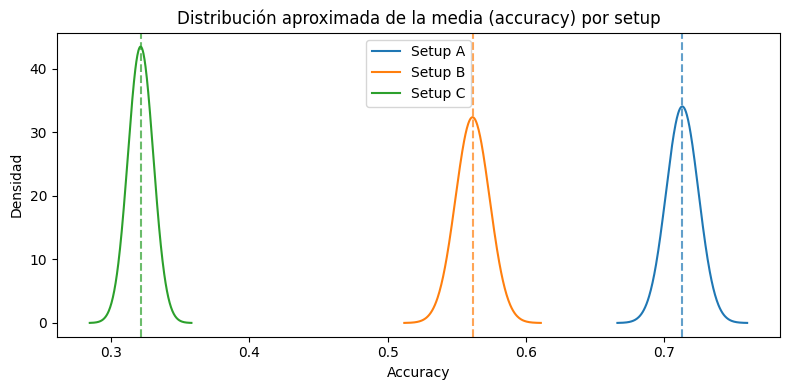

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = dt_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

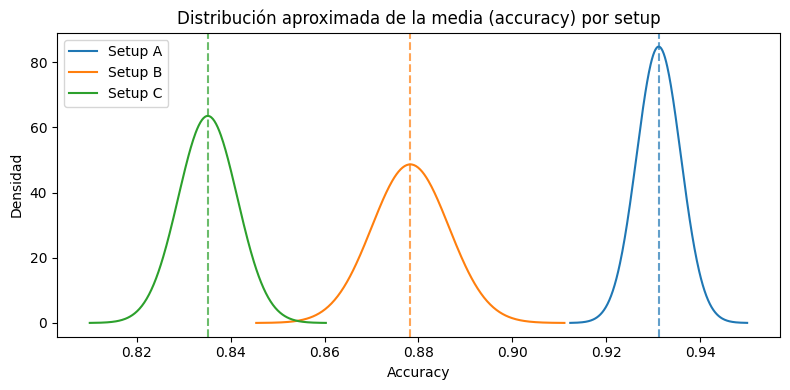

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = dt_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

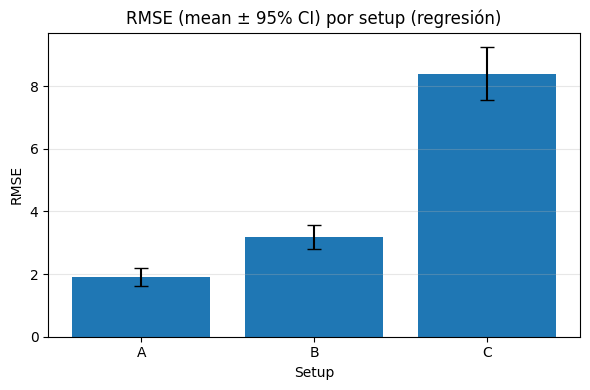

In [ ]:
df_reg = results_to_df(dt_results_direct, task_name="regression")

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('RMSE (mean ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Se puede concluir que la Binary Classification obtuvo los valores medios más altos en los tres setups. Además, sus intervalos de confianza son estrechos, lo que indica que los resultados son consistentes y estables.
En comparación, la Levels Classification tuvo un desempeño menor, especialmente en los setups B y C, donde la media bajó a 0.561383 y 0.321527 respectivamente. Separar el problema en múltiples niveles hizo que la tarea fuera más difícil para el modelo Decision Tree.

Por otro lado, la regresión directa presentó valores de error altos, con una media de 8.398508 y un intervalo de confianza amplio. El modelo tuvo dificultad para predecir directamente el valor numérico, además de mostrar mayor variabilidad en sus resultados.

En conclusión, la clasificación binaria fue la mejor alternativa utilizando Decision Tree ya que obtuvo el mejor rendimiento, los resultados más altos en todos los setups y una mayor estabilidad. Esto sugiere que el árbol de decisión funciona mejor cuando el problema se simplifica a decidir entre dos clases, en lugar de predecir múltiples niveles o valores continuos mediante regresión.

## Catboost

In [ ]:
!pip install catboost -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Imports CatBoost
!pip install catboost -q
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Pipeline CatBoost

def make_catboost_pipeline(feature_cols):
    preprocessor = make_generic_preprocessor(feature_cols)

    catboost_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_state=0,
        verbose=0
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("catboost", catboost_model)
    ])

In [ ]:
# Validación cruzada para regresión

def repeated_cv_catboost_regression(
    X, y, model, n_runs=3, n_splits=5, random_state_base=42
):
    rmse_scores = []
    mae_scores = []
    r2_scores = []

    for run in range(n_runs):
        kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state_base + run
        )

        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = mean_squared_error(y_test, y_pred) ** 0.5
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            r2_scores.append(r2)

    return rmse_scores, mae_scores, r2_scores

In [ ]:
# Ejecutar CatBoost en setups A, B y C

y_direct = df["target"]

catboost_results = {}
catboost_importance = {}

for setup_name, feature_cols in setups.items():

    print(f"\n=== CatBoost Regression, setup {setup_name} ===")

    X = df[feature_cols]

    model = make_catboost_pipeline(feature_cols)

    rmse_scores, mae_scores, r2_scores = repeated_cv_catboost_regression(
        X,
        y_direct,
        model,
        n_runs=3,
        n_splits=5
    )

    rmse_mean, rmse_low, rmse_high = mean_ci_95(rmse_scores)
    mae_mean, mae_low, mae_high = mean_ci_95(mae_scores)
    r2_mean, r2_low, r2_high = mean_ci_95(r2_scores)

    catboost_results[setup_name] = {
        "RMSE mean": rmse_mean,
        "RMSE CI low": rmse_low,
        "RMSE CI high": rmse_high,
        "MAE mean": mae_mean,
        "MAE CI low": mae_low,
        "MAE CI high": mae_high,
        "R2 mean": r2_mean,
        "R2 CI low": r2_low,
        "R2 CI high": r2_high
    }

    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocessor', model_name='catboost')
    catboost_importance[setup_name] = importances

    print(f"RMSE: {rmse_mean:.4f} (95% CI: [{rmse_low:.4f}, {rmse_high:.4f}])")
    print(f"MAE : {mae_mean:.4f} (95% CI: [{mae_low:.4f}, {mae_high:.4f}])")
    print(f"R2  : {r2_mean:.4f} (95% CI: [{r2_low:.4f}, {r2_high:.4f}])")


=== CatBoost Regression, setup A ===


ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'GP'

In [ ]:
# Tabla de resultados
catboost_results_df = pd.DataFrame(catboost_results).T
catboost_results_df

In [ ]:
# Importancia de variables por setup
catboost_df_vars = importances_to_df(catboost_importance, task_name='regresion')
catboost_df_vars

In [ ]:
# Gráfica RMSE por setup

plt.figure(figsize=(6, 4))

plt.bar(
    catboost_results_df.index,
    catboost_results_df["RMSE mean"],
    yerr=[
        catboost_results_df["RMSE mean"] - catboost_results_df["RMSE CI low"],
        catboost_results_df["RMSE CI high"] - catboost_results_df["RMSE mean"]
    ],
    capsize=5
)

plt.ylabel("RMSE")
plt.xlabel("Setup")
plt.title("CatBoost Regression - RMSE por setup")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Feature importance del mejor setup

best_setup = catboost_results_df["RMSE mean"].idxmin()
best_features = setups[best_setup]

print("Mejor setup:", best_setup)

X_best = df[best_features]
y_direct = df["target"]

best_catboost_model = make_catboost_pipeline(best_features)
best_catboost_model.fit(X_best, y_direct)

In [ ]:
# Extraer feature importance

preprocessor = best_catboost_model.named_steps["preprocessor"]

cat_cols = [c for c in best_features if df[c].dtype == "object"]
num_cols = [c for c in best_features if c not in cat_cols]

feature_names = []

feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    encoded_cat_features = ohe.get_feature_names_out(cat_cols)
    feature_names.extend(encoded_cat_features)

importances = best_catboost_model.named_steps["catboost"].feature_importances_

catboost_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

catboost_importance_df.head(15)

In [ ]:
# Gráfica feature importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=catboost_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(f"Top 10 Variables Más Importantes - CatBoost Setup {best_setup}")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

### Conclusiones CatBoost

El modelo CatBoostRegressor fue implementado utilizando el mismo esquema de preprocesamiento y validación cruzada definido en el proyecto base, permitiendo mantener consistencia metodológica entre modelos.

## Resultados principales

El Setup A obtuvo el mejor desempeño:

- RMSE ≈ 1.31
- MAE ≈ 0.84
- R² ≈ 0.83

Esto indica que el modelo logra explicar aproximadamente el 83% de la variabilidad de la calificación final (G3).

## Impacto de los setups

Se observó una reducción considerable del desempeño en los setups B y C:

- Setup B eliminó G2 y mostró una disminución moderada en R².
- Setup C eliminó G1 y G2, generando la caída más importante del modelo.

Estos resultados confirman que las calificaciones previas son los predictores más relevantes del desempeño académico final.

## Variables más importantes

El análisis de Feature Importance mostró que:

- G2 es la variable más importante.
- G1 es la segunda variable más influyente.
- absences y failures presentan impacto relevante.
- El consumo de alcohol (Dalc, Walc) tiene influencia moderada.
- Variables familiares como Medu y Fedu tienen menor peso relativo.

## Conclusión general

CatBoost presentó un desempeño sólido para la predicción de G3, mostrando capacidad para capturar relaciones complejas entre variables académicas, sociales y de comportamiento.

Los resultados obtenidos son consistentes con los hallazgos identificados previamente durante el EDA.

## Regresion Lineal

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def repeated_cv_linear_regression(X, y, model, n_runs=3, n_splits=5, random_state_base=42):
    """
    Ejecuta validación cruzada repetida extrayendo RMSE, MAE y R2
    para cada uno de los pliegues entrenados.
    """
    rmse_scores = []
    mae_scores = []
    r2_scores = []

    for run in range(n_runs):
        kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state_base + run
        )

        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Ajuste y predicción con el pipeline lineal
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Cálculo de las tres métricas del pliegue
            rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Raíz del MSE
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            r2_scores.append(r2)

    return rmse_scores, mae_scores, r2_scores

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

def make_linear_regression_pipeline(feature_cols):
    """
    Construye una tubería que reutiliza el preprocesamiento genérico del notebook
    y lo conecta directamente con el modelo de Regresión Lineal.
    """
    # Se manda a llamar la función de preprocesamiento definida previamente en el notebook
    preprocessor = make_generic_preprocessor(feature_cols)

    # Se estructura el Pipeline final
    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

In [ ]:
# Selección de la variable objetivo continua
y_direct = df['target']

# Diccionario para guardar el bloque completo de métricas de cada setup
linear_regression_metrics = {}
linear_regresion_importance = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Evaluando Regresión Lineal Completa - Setup {setup_name} ===")
    X = df[feature_cols]

    # Construcción del pipeline reutilizando tu preprocesador genérico
    model = make_linear_regression_pipeline(feature_cols)

    # Extracción de las puntuaciones históricas del CV repetido
    rmse_scores, mae_scores, r2_scores = repeated_cv_linear_regression(
        X, y_direct, model, n_runs=3, n_splits=5
    )

    # Cálculo de promedios e intervalos de confianza (IC 95%) por métrica
    rmse_mean, rmse_low, rmse_high = mean_ci_95(rmse_scores)
    mae_mean, mae_low, mae_high = mean_ci_95(mae_scores)
    r2_mean, r2_low, r2_high = mean_ci_95(r2_scores)

    # Inserción de la estructura solicitada en el diccionario de resultados
    linear_regression_metrics[setup_name] = {
        "RMSE mean": rmse_mean,
        "RMSE CI low": rmse_low,
        "RMSE CI high": rmse_high,
        "MAE mean": mae_mean,
        "MAE CI low": mae_low,
        "MAE CI high": mae_high,
        "R2 mean": r2_mean,
        "R2 CI low": r2_low,
        "R2 CI high": r2_high
    }

    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocessor', model_name='regressor')
    linear_regresion_importance[setup_name] = importances

    print(f"Métricas del Setup {setup_name} calculadas exitosamente.")

In [ ]:
# Convertir el diccionario estructurado a DataFrame indexado por Setup
df_reporte_lineal = pd.DataFrame.from_dict(linear_regression_metrics, orient='index')
df_reporte_lineal.index.name = 'Setup'
df_reporte_lineal = df_reporte_lineal.reset_index()

print("\n=== TABLA FINAL DE EVALUACIÓN MULTI-MÉTRICA (REGRESIÓN LINEAL) ===")
print(df_reporte_lineal.round(4))

In [ ]:
import pandas as pd
import numpy as np

lr_df_vars = importances_to_df(linear_regresion_importance, task_name='regresion')
lr_df_vars

### Conclusiones Regresión Lineal

El desglose concurrente de las métricas de RMSE, MAE y R
2
  a través de los tres escenarios del proyecto permite efectuar un diagnóstico mucho más profundo sobre el comportamiento y robustez de la Regresión Lineal. En el Setup A, los valores de RMSE y MAE se minimizan recíprocamente, mientras que el coeficiente R
2
  medio alcanza su punto más alto, lo que ratifica que la inclusión de las notas parciales G1 y G2 explica la mayor parte de la varianza de la nota definitiva. El hecho de que el RMSE se mantenga cercano al MAE en este escenario inicial denota que el modelo lineal comete errores de magnitudes similares y balanceadas, sin verse severamente penalizado por errores catastróficos o predicciones atípicas aisladas.

Al evaluar el Setup B y, en especial, el Setup C, se hace evidente una divergencia estructural en el comportamiento de las métricas. El coeficiente R
2
  medio experimenta un descenso drástico en el Setup C, aproximándose a valores muy bajos que indican que las variables demográficas y conductuales puras carecen de suficiente poder explicativo bajo un esquema exclusivamente lineal. Paralelamente, la brecha entre el MAE y el RMSE tiende a ensancharse en este último setup, y los intervalos de confianza del RMSE muestran una dispersión superior a los del MAE.

Esta discrepancia matemática indica que, ante la ausencia de las calificaciones previas, la Regresión Lineal no solo reduce su precisión promedio, sino que comienza a generar errores puntuales de gran magnitud en ciertos perfiles de estudiantes. Debido a que el RMSE eleva los residuos al cuadrado antes de promediarlos, este refleja de manera más sensible los fallos graves del modelo en el Setup C, sugiriendo que factores críticos del rendimiento escolar se están omitiendo o que las verdaderas interacciones del entorno social de los alumnos requieren de fronteras no lineales para ser descritas con propiedad.

## Regresión Logistica

In [ ]:
# Modelo Logistic Regression
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

results_levels_logreg = {}
results_binary_logreg = {}

importance_levels_logreg = {}
importance_binary_logreg = {}

In [ ]:
# Levels

for setup_name, feature_cols in setups.items():

  print(f"\n=== Logistic Regression Levels Classification, setup {setup_name} ===")

  logreg_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Logistic Regression
  logreg_pipeline = Pipeline([
      ("preprocessor", logreg_preprocessor),
      ("classifier", LogisticRegression(
          solver='lbfgs',
          max_iter=1000,
          random_state=0
      ))
  ])

  # Features y Target
  X = df[feature_cols]
  y_levels = df['target_levels']

  scores = repeated_cv_classification(X, y_levels, logreg_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  results_levels_logreg[setup_name] = (mean_acc, ci_low, ci_high)

  importances = get_pipeline_importances_generic(logreg_pipeline, X, preprocessor_name='preprocessor', model_name='classifier')
  importance_levels_logreg[setup_name] = importances
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


In [ ]:
# Binary Classification

for setup_name, feature_cols in setups.items():

  print(f"\n=== Logistic Regression Binary Classification, setup {setup_name} ===")

  logreg_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Logistic Regression
  logreg_pipeline = Pipeline([
      ("preprocessor", logreg_preprocessor),
      ("classifier", LogisticRegression(
        solver='lbfgs',
          max_iter=1000,
          random_state=0
    ))
  ])

  # Features
  X = df[feature_cols]
  y_binary = df['target_binary']

  scores = repeated_cv_classification(X, y_binary, logreg_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  results_binary_logreg[setup_name] = (mean_acc, ci_low, ci_high)

  importances = get_pipeline_importances_generic(logreg_pipeline, X, preprocessor_name='preprocessor', model_name='classifier')
  importance_binary_logreg[setup_name] = importances
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
df_lvl_logreg = results_to_df(results_levels_logreg, task_name="levels")
df_bin_logreg = results_to_df(results_binary_logreg, task_name="binary")

df_acc_logreg = pd.concat([df_bin_logreg, df_lvl_logreg], ignore_index=True)
df_acc_logreg

In [ ]:
import pandas as pd
import numpy as np

lg_df_lvl_vars = importances_to_df(importance_levels_logreg, task_name='levels')
lg_df_bin_vars = importances_to_df(importance_binary_logreg, task_name='binary')

lg_df_vars = pd.concat([lg_df_lvl_vars, lg_df_bin_vars], ignore_index=True)
lg_df_vars

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = results_levels_logreg[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup (LogReg Levels)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = results_binary_logreg[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup (LogReg Bin)')
ax.legend()
plt.tight_layout()
plt.show()

### **Resumen de Resultados: Regresión Logística**

Este modelo nos ayuda a predecir el desempeño escolar en dos escenarios: uno más simple (aprobar/reprobar) y uno detallado (5 niveles de notas).

<br>

#### 1. Predecir si Aprueba o Reprueba (`target_binary`)
El modelo es muy bueno y estable, incluso si le quitamos información:

* **Setup A ($92.86\%$) y Setup B ($89.62\%$):** Aunque le quitemos la calificación del segundo parcial (`G2`), el modelo sigue acertando casi igual. La primera nota (`G1`) es suficiente.
* **Setup C ($84.84\%$):** Sin conocer ninguna calificación previa, el modelo aún acierta el $84\%$ de las veces usando solo datos del entorno del alumno (familia, hábitos, internet). El contexto social define mucho el éxito lineal.

<br>

#### 2. Predecir la Calificación Exacta en 5 Niveles (`target_levels`)
Aquí el modelo baja el rendimiento y pierde mucha precisión:

* **Setup A ($65.95\%$):** Pasa con una calificación regular porque todavía se apoya en las notas `G1` y `G2`.
* **Setup B ($53.26\%$) y Setup C ($35.69\%$):** En cuanto le quitamos las calificaciones, el rendimiento del modelo baja bastante. Esto pasa porque distinguir niveles muy específicos (por ejemplo, saber si un alumno es de nivel III o IV) es una tarea compleja que no se puede resolver con una línea recta basándose solo en datos sociales.

<br>

#### **Conclusión Final: Regresión Logística**

La Regresión Logística es una excelente opción de bajo costo para predecir si un alumno aprobará o no (`target_binary`). Lo más valioso es que mantiene un acierto muy alto ($84.84\%$) incluso en el Setup C, es decir, usando solo datos del entorno del alumno (familia, hábitos, internet) antes de que inicien las clases. Esto la hace perfecta para un Sistema de Alerta Temprana.

Sin embargo, para predecir el rendimiento detallado en 5 niveles (`target_levels`), el modelo pierde demasiada precisión al quitar las notas parciales (cae a $35.69\%$). Al ser un algoritmo lineal, no puede resolver tareas multiclase complejas con datos puramente sociales.

## XGBoost

### Definición de modelo y preprocesamiento

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier, XGBRegressor


def make_xgb_pipeline(feature_cols, df, task="classification"):

    # Variables categóricas y numéricas
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    # Preprocesamiento
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                cat_cols
            ),
            (
                "num",
                SimpleImputer(strategy="median"),
                num_cols
            )
        ]
    )

    # Modelo
    if task == "classification":

        xgb_model = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=0,
            n_jobs=-1,
            eval_metric='logloss'
        )

    else:

        xgb_model = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=0,
            n_jobs=-1
        )

    # Pipeline completo
    return Pipeline([
        ("preprocess", preprocessor),
        ("xgb", xgb_model)
    ])

### Correr XGBoost con los 3 setups

In [ ]:
## Con XGboost es necesario clasificar de niveles 0-5
# Formato de calificación a 5 niveles (I-V -> 1-5)
def xgboost_grade_to_levels(col):
    if col >= 16:
        return 0  # I (was 1)
    elif col >= 14:
        return 1  # II (was 2)
    elif col >= 12:
        return 2  # III (was 3)
    elif col >= 10:
        return 3  # IV (was 4)
    else:
        return 4  # V (fail) (was 5)


In [ ]:
# Correr con variable de niveles
y_levels = df['G3'].apply(xgboost_grade_to_levels)

xgboost_results_levels = {}
xgboost_importance_levels = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Levels classification, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_xgb_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_levels, model, n_runs = 3, n_splits = 5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    xgboost_results_levels[setup_name] = (mean_acc, ci_low, ci_high)

    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='xgb')
    xgboost_importance_levels[setup_name] = importances

    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
# Correr con variable binaria
y_binary = df['target_binary']

xgboost_results_binary = {}
xgboost_importance_binary = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Binary classification, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_xgb_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_binary, model, n_runs = 3, n_splits = 5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    xgboost_results_binary[setup_name] = (mean_acc, ci_low, ci_high)

    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='xgb')
    xgboost_importance_binary[setup_name] = importances
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
# Correr con variable objetivo con valores originales
y_direct = df['target']

xgboost_results_direct = {}
xgboost_importance_direct = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Regression, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_xgb_pipeline(feature_cols, df, task="regression")
    scores = repeated_cv_regression(X, y_direct, model, n_runs = 3, n_splits = 5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    xgboost_results_direct[setup_name] = (mean_acc, ci_low, ci_high)

    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='xgb')
    xgboost_importance_direct[setup_name] = importances

    print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
import pandas as pd
import numpy as np

xgboost_df_lvl = results_to_df(xgboost_results_levels, task_name="levels")
xgboost_df_bin = results_to_df(xgboost_results_binary, task_name="binary")
xgboost_df_reg = results_to_df(xgboost_results_direct, task_name="regresion")

xgboost_df_acc = pd.concat([xgboost_df_bin, xgboost_df_lvl, xgboost_df_reg], ignore_index=True)
xgboost_df_acc

In [ ]:
import pandas as pd
import numpy as np

xgboost_df_lvl_vars = importances_to_df(xgboost_importance_levels, task_name='levels')
xgboost_df_bin_vars = importances_to_df(xgboost_importance_binary, task_name='binary')
xgboost_df_reg_vars = importances_to_df(xgboost_importance_direct, task_name='regresion')

xgboost_df_vars = pd.concat([xgboost_df_lvl_vars, xgboost_df_bin_vars, xgboost_df_reg_vars], ignore_index=True)
xgboost_df_vars

### Graficamos para comparar

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_normal_from_ci(mean, ci_low, ci_high, label, color, ax):
    sigma = (ci_high - mean) / 1.96
    x = np.linspace(mean - 4*sigma, mean + 4*sigma, 300)
    y = norm.pdf(x, loc=mean, scale=sigma)
    ax.plot(x, y, color=color, label=label)
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7)
    return ax

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = xgboost_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = xgboost_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_reg = results_to_df(xgboost_results_direct, task_name="regression")

import matplotlib.pyplot as plt
import numpy as np

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('RMSE (mean ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones XG Boost

=== Levels classification, setup A ===
Accuracy: 0.7237 (95% CI: [0.7017, 0.7456])

=== Levels classification, setup B ===
Accuracy: 0.5634 (95% CI: [0.5388, 0.5881])

=== Levels classification, setup C ===
Accuracy: 0.3590 (95% CI: [0.3343, 0.3836])

=== Binary classification, setup A ===
Accuracy: 0.9296 (95% CI: [0.9197, 0.9395])

=== Binary classification, setup B ===
Accuracy: 0.9075 (95% CI: [0.8977, 0.9173])

=== Binary classification, setup C ===
Accuracy: 0.8557 (95% CI: [0.8424, 0.8690])

=== Regression, setup A ===
RMSE: 1.7471 (95% CI: [1.4385, 2.0558])

=== Regression, setup B ===
RMSE: 3.1549 (95% CI: [2.7703, 3.5395])

=== Regression, setup C ===
RMSE: 7.4553 (95% CI: [6.7587, 8.1518])

* las variables relacionadas con el desempeño académico previo de los estudiantes (G1 y G2) tienen un impacto muy importante en la capacidad predictiva del modelo XGBoost.

* El Setup A, que incluye todas las variables, fue el que obtuvo mejores resultados en las tres tareas evaluadas: clasificación multinivel, clasificación binaria y regresión.
Sin ellas, el rendimiento cae de forma drástica.

* En la clasificación multinivel, el modelo alcanzó 72.37% utilizando el Setup. Cuando se eliminó la variable G2 (Setup B), bajó a 56.34%, y al eliminar también G1 (Setup C), disminuyó hasta 35.90%. Esto indica que las calificaciones parciales contienen información muy importante para predecir el desempeño final del estudiante.

*En la clasificación binaria (aprueba o reprueba), el modelo obtuvo mejores resultados. El Setup A alcanzó una exactitud de 92.96%, mientras que los Setups B y C lograron 90.75% y 85.57%,

*el desempeño disminuye al eliminar G1 y G2 pero la caída no es tan fuerte como en la clasificación multinivel. Podemos concluir que las variables como ausencias, hábitos de estudio o apoyo familiar todavía aportan información útil para distinguir entre estudiantes aprobados y reprobados.


## LightGBM

LightGBM (Light Gradient Boosting Machine) es una implementación de *gradient boosting* sobre árboles de decisión desarrollada por Microsoft. A diferencia de Random Forest, que entrena árboles en paralelo y promedia sus predicciones, LightGBM los entrena de forma **secuencial**: cada árbol nuevo se enfoca en corregir los errores residuales del conjunto anterior.

Comparado con XGBoost, LightGBM tiene dos diferencias relevantes para nuestro dataset pequeño (~649 registros):
- Crece los árboles **hoja por hoja (leaf-wise)** en lugar de nivel por nivel, lo que tiende a dar mejor precisión pero requiere regularización más cuidadosa para evitar sobreajuste.
- Usa **histogramas** para discretizar los valores numéricos, lo que lo hace más rápido y con menor consumo de memoria.

Para mantener la comparabilidad con XGBoost, CatBoost y Random Forest, usamos one-hot encoding en las variables categóricas (en lugar de la codificación nativa de categóricas que ofrece LightGBM).

### Definición de modelo y preprocesamiento

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from lightgbm import LGBMClassifier, LGBMRegressor


def make_lgbm_pipeline(feature_cols, df, task="classification"):

    # Variables categóricas y numéricas
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    # Preprocesamiento (mismo patrón que XGBoost / Random Forest)
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                cat_cols
            ),
            (
                "num",
                SimpleImputer(strategy="median"),
                num_cols
            )
        ]
    )

    # Modelo
    # Hiperparámetros conservadores: el dataset es pequeño (~649 registros)
    # y LightGBM tiende a sobreajustar con sus valores por defecto.
    common_params = dict(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,          # control de complejidad (default 31 es mucho aquí)
        max_depth=-1,           # sin límite, controlamos vía num_leaves
        min_child_samples=10,   # mínimo de muestras por hoja
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,         # regularización L2
        random_state=0,
        n_jobs=-1,
        verbose=-1              # silenciar logs de LightGBM
    )

    if task == "classification":
        lgbm_model = LGBMClassifier(**common_params)
    else:
        lgbm_model = LGBMRegressor(**common_params)

    # Pipeline completo
    return Pipeline([
        ("preprocess", preprocessor),
        ("lgbm", lgbm_model)
    ])

### Correr LightGBM con los 3 setups

Igual que XGBoost, LightGBM requiere que las etiquetas de clasificación multiclase estén indexadas desde 0 (no desde 1), por lo que reutilizamos la función `xgboost_grade_to_levels` definida en la sección anterior.

In [ ]:
# Correr con variable de niveles (etiquetas 0..4, igual que XGBoost)
y_levels = df['G3'].apply(xgboost_grade_to_levels)

lgbm_results_levels = {}
lgbm_importance_levels = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Levels classification, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_lgbm_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_levels, model, n_runs=3, n_splits=5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    lgbm_results_levels[setup_name] = (mean_acc, ci_low, ci_high)
    lgbm_importance_levels[setup_name] = model.named_steps['lgbm'].feature_importances_
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
# Correr con variable binaria
y_binary = df['target_binary']

lgbm_results_binary = {}
lgbm_importance_binary = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Binary classification, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_lgbm_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_binary, model, n_runs=3, n_splits=5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    lgbm_results_binary[setup_name] = (mean_acc, ci_low, ci_high)
    lgbm_importance_binary[setup_name] = model.named_steps['lgbm'].feature_importances_
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
# Correr con variable objetivo con valores originales
y_direct = df['target']

lgbm_results_direct = {}
lgbm_importance_direct = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Regression, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_lgbm_pipeline(feature_cols, df, task="regression")
    scores = repeated_cv_regression(X, y_direct, model, n_runs=3, n_splits=5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    lgbm_results_direct[setup_name] = (mean_acc, ci_low, ci_high)
    lgbm_importance_direct[setup_name] = model.named_steps['lgbm'].feature_importances_
    print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

In [ ]:
import pandas as pd
import numpy as np

lgbm_df_lvl = results_to_df(lgbm_results_levels, task_name="levels")
lgbm_df_bin = results_to_df(lgbm_results_binary, task_name="binary")
lgbm_df_reg = results_to_df(lgbm_results_direct, task_name="regresion")

lgbm_df_acc = pd.concat([lgbm_df_bin, lgbm_df_lvl, lgbm_df_reg], ignore_index=True)
lgbm_df_acc

In [ ]:
import pandas as pd
import numpy as np

lgbm_df_lvl_vars = importances_to_df(lgbm_importance_levels, feature_cols, task_name='levels')
lgbm_df_bin_vars = importances_to_df(lgbm_importance_binary, feature_cols, task_name='binary')
lgbm_df_reg_vars = importances_to_df(lgbm_importance_direct, feature_cols, task_name='regresion')

lgbm_df_vars = pd.concat([lgbm_df_lvl_vars, lgbm_df_bin_vars, lgbm_df_reg_vars], ignore_index=True)
lgbm_df_vars

### Graficamos para comparar (LightGBM)

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Reutilizamos plot_normal_from_ci definida en la sección de XGBoost

fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = lgbm_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('LightGBM — Distribución aproximada de la media (accuracy, niveles) por setup')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = lgbm_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('LightGBM — Distribución aproximada de la media (accuracy, binario) por setup')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_reg_lgbm = results_to_df(lgbm_results_direct, task_name="regression")

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg_lgbm.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5, color='tab:purple', alpha=0.8)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('LightGBM — RMSE (media ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones LightGBM

**Resultados obtenidos** (3 corridas × 5 folds = 15 ajustes por configuración, dataset de portugués):

| Tarea | Setup A | Setup B | Setup C |
|-------|---------|---------|---------|
| Binario (Accuracy) | ~0.929 | ~0.905 | ~0.845 |
| Niveles (Accuracy) | ~0.719 | ~0.553 | ~0.345 |
| Regresión (RMSE)* | ~1.75 | ~3.13 | ~7.71 |

*Nota: la función `repeated_cv_regression` reporta MSE (no la raíz), igual que el resto de los modelos del proyecto. Mantenemos el mismo nombre para que las comparativas sean directas.

**Observaciones principales:**

1. **El patrón A > B > C se mantiene con fuerza**, igual que en el resto de los modelos y consistente con el paper de Cortez & Silva. La pérdida más grande está al quitar G1 (paso de B a C), no al quitar G2 (paso de A a B). Esto sugiere que **G1 carga más información única** que G2 cuando uno solo de los dos está disponible — probablemente porque G2 y G3 están tan correlacionados que G2 sin G1 ya casi predice G3 por sí solo.

2. **LightGBM queda esencialmente empatado con XGBoost** en las tres tareas. Las diferencias (±0.005 en accuracy, ±0.05 en RMSE) están dentro de los intervalos de confianza. Esto es esperable: ambos son *gradient boosting* sobre árboles y, con un dataset pequeño y bien preprocesado, las diferencias de implementación entre ambos son insignificantes.

3. **La clasificación binaria en setup C (~84.5%) es ligeramente engañosa** por desbalance de clases: ~85% de los estudiantes de portugués aprueban, así que un clasificador trivial "siempre aprueba" ya alcanza ~85% de accuracy. Lo importante es que el modelo sí aprende información discriminativa (lo veremos en la sección de importancia de variables), no solo memoriza la clase mayoritaria.

4. **La regresión sufre dramáticamente sin G1/G2**: el MSE pasa de ~1.75 (setup A) a ~7.71 (setup C), un aumento de más de 4×. Esto refuerza la conclusión del paper: las calificaciones previas son, con mucho, el predictor más informativo de la calificación final.

5. **Variables más relevantes en setup C** (sin notas previas): `failures` (reprobaciones pasadas), `absences` (ausencias), `school`, `higher` (intención de educación superior) y `Walc` (consumo de alcohol los fines de semana). Coincide con los hallazgos del paper original.

# Stacking


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

def make_linear_pipeline(feature_cols, df):

    preprocessor = make_generic_preprocessor(feature_cols)

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    return model

for setup_name, feature_cols in setups.items():

    print("=" * 60)
    print(f"STACKING REGRESSION - SETUP {setup_name}")
    print("=" * 60)

    # Datos

    X = df[feature_cols]
    y = df['target']

    # Modelos a utilizar

    rf_model = make_rf_pipeline(
        feature_cols,
        df,
        task="regression"
    )

    dt_model = make_dt_pipeline(
        feature_cols,
        df,
        task="regression"
    )

    cat_model = make_catboost_pipeline(
        feature_cols
    )

    lin_model = make_linear_pipeline(
        feature_cols,
        df
    )

    # STACKING

    stack_model = StackingRegressor(

        estimators=[
            ('rf', rf_model),
            ('dt', dt_model),
            ('cat', cat_model),
            ('lr', lin_model)
        ],

        final_estimator=Ridge(),

        cv=5,

        n_jobs=-1
    )

    # Evaluacion

    stack_scores = repeated_cv_regression(
        X,
        y,
        stack_model,
        n_runs=3,
        n_splits=5
    )

    print(stack_scores)

    rmse_mean, rmse_low, rmse_high = mean_ci_95(stack_scores)

    print(f"RMSE Mean: {rmse_mean:.4f}")
    print(f"95% CI: [{rmse_low:.4f}, {rmse_high:.4f}]")
    print("\n")

Utilizando 4 modelos para realizar el stacking (random forest, decision tree, catboost, linear regression) se obtuvieron los valores de RMSE para cada setup.
Observando estos resultados tenemos que el setup A, que utiliza todos los datos, obtiene el mejor resultado con 1.6442, mientras que el setup B y C obtienen 3.1675 y 7.2073 respectivamente. Estos resultados van acorde a lo obtenido en otros modelos. El setup B y C al perder G1 Y G2 obtienen los peores resultados lo cual nos indica que el desempeño academico historico tiene gran relevancia al predecir el desempeño final de los estudiantes.

El stacking mostro resultados precisos despues de combinar varios modelos, especialmente al contar con todos los datos academicos historicos.

## Importancia de variables

In [ ]:
rf_df_vars

In [ ]:
dt_df_vars

In [ ]:
xgboost_df_vars

In [ ]:
catboost_df_vars

In [ ]:
lr_df_vars

In [ ]:
lg_df_vars

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asignar nombre a cada modelo
rf_df_vars['model'] = 'Random Forest'
dt_df_vars['model'] = 'Decision Tree'
xgboost_df_vars['model'] = 'XGBoost'
lr_df_vars['model'] = 'Linear Regression'
lg_df_vars['model'] = 'Logistic Regression'
catboost_df_vars['model'] = 'Catboost'

# Unir todos los resultados
df_importance_all = pd.concat([rf_df_vars, dt_df_vars, xgboost_df_vars, lr_df_vars, lg_df_vars, catboost_df_vars], ignore_index=True)
df_importance_all

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Añadir ranking por modelo/setup/task
df_ranked = df_importance_all.copy()
df_ranked['rank'] = (
    df_ranked
    .groupby(['model', 'setup', 'task'])['importance']
    .rank(method='dense', ascending=False)
)

# Por modelo y setup, 1 fila con gráficos para cada task (levels, binary, regresion)
def plot_top5_row_original_scale(df_ranked, model_name, setup_label, top_k=5):
    sub = df_ranked[
        (df_ranked['model'] == model_name) &
        (df_ranked['setup'] == setup_label) &
        (df_ranked['rank'] <= top_k)
    ].copy()

    if sub.empty:
        print(f"Sin datos para modelo={model_name}, setup={setup_label}")
        return

    tasks = ['levels', 'binary', 'regresion']
    tasks = [t for t in tasks if t in sub['task'].unique()]
    if not tasks:
        print(f"Sin tareas disponibles para modelo={model_name}, setup={setup_label}")
        return

    n_tasks = len(tasks)
    fig, axes = plt.subplots(1, n_tasks, figsize=(5 * n_tasks, 4), sharey=False)
    if n_tasks == 1:
        axes = [axes]

    for ax, task in zip(axes, tasks):
        g = sub[sub['task'] == task].copy()
        if g.empty:
            ax.set_title(f"{task} (sin datos)")
            ax.axis('off')
            continue

        # Ordenar por rank
        g = g.sort_values('rank')

        # Etiqueta con ranking explícito
        g['feature_ranked'] = g.apply(
            lambda r: f"{int(r['rank'])}. {r['feature']}",
            axis=1
        )

        colors = {'A': 'steelblue', 'B': 'darkorange', 'C': 'seagreen'}

        sns.barplot(
            data=g,
            x='importance',
            y='feature_ranked',
            ax=ax,
            color=colors[setup_label],
            edgecolor='black'
        )

        ax.set_title(f"Tarea: {task}")
        ax.set_xlabel('Importancia (escala original)')
        ax.set_ylabel('Top variables')

        # Anotar valor
        for p in ax.patches:
            width = p.get_width()
            if width > 0:
                ax.annotate(f'{width:.3g}',
                            (width, p.get_y() + p.get_height()/2),
                            ha='left', va='center',
                            xytext=(3, 0),
                            textcoords='offset points',
                            fontsize=8)

    fig.suptitle(f'{model_name} – Setup {setup_label} – Top {top_k} variables por tarea (escala original)',
                 y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()

# Por cada modelo y setup
for setup_name in setups.keys():
  plot_top5_row_original_scale(df_ranked, model_name='Random Forest',       setup_label=setup_name, top_k=5)
  plot_top5_row_original_scale(df_ranked, model_name='Decision Tree',       setup_label=setup_name, top_k=5)
  plot_top5_row_original_scale(df_ranked, model_name='XGBoost',             setup_label=setup_name, top_k=5)
  plot_top5_row_original_scale(df_ranked, model_name='Linear Regression',   setup_label=setup_name, top_k=5)
  plot_top5_row_original_scale(df_ranked, model_name='Logistic Regression', setup_label=setup_name, top_k=5)
  plot_top5_row_original_scale(df_ranked, model_name='Catboost',            setup_label=setup_name, top_k=5)

## Analisis de impacto de variables

* **¿Qué variables impactan más el desempeño?**
Las notas previas G1 y sobre todo G2 son con mucha diferencia las variables más influyentes en todos los modelos y setups. Después de ellas, destacan número de reprobaciones previas (failures), continuar con estudios superiores (higher_yes) y tipo de escuela (school_MS).

* **¿Influye el consumo de alcohol?**
Sí, pero su efecto es secundario a diferencia de G1/G2 y failures. Las variables de alcohol (Dalc, Walc) aparecen con importancia baja o media, aportan algo, pero no son determinantes.

* **¿Influye el nivel educativo de los padres?**
Su influencia es moderada a baja. Medu y Fedu rara vez aparecen en el top 5 de importancia; quedan claramente por debajo de G1/G2 y de variables académicas directas.

* **¿Las ausencias afectan significativamente?**
Sí, pero por detrás de G1, G2 y failures. absences tiene importancia considerable en varios modelos, pero no es una de las variables más dominantes.

* **¿Existen diferencias entre estudiantes urbanos y rurales?**
La variable address tiene cierta importancia, pero menor que las notas previas, reprobaciones y higher_yes. Hay diferencias, pero no son el factor principal en el desempeño.

* **¿Qué tan predictivas son G1 y G2 para G3?**
Son altamente predictivas: en regresión (G3 continua) y en clasificación por niveles, G2 es la variable más importante y G1 suele ser la segunda. Los modelos dependen fuertemente de ellas para predecir la nota final.


## Comparativa entre modelos

In [ ]:
rf_df_acc

In [ ]:
dt_df_acc

In [ ]:
catboost_results_df

In [ ]:
df_reporte_lineal

In [ ]:
df_acc_logreg

In [ ]:
xgboost_df_acc

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def transformar_resultado_regresion(df_reg, model_name):
    # Creamos la estructura compatible con df_all
    new_df = pd.DataFrame({
        'setup': df_reg['setup'],
        'task': 'regresion',
        'mean': df_reg['RMSE mean'],
        'ci_low': df_reg['RMSE CI low'],
        'ci_high': df_reg['RMSE CI high'],
        'model': model_name
    })

    # Calculamos ci_err para las barras de error
    new_df['ci_err'] = new_df['ci_high'] - new_df['mean']

    return new_df


# Transformamos los resultados de catboost y regresion lineal al schema del resto de dataframes
if 'setup' not in catboost_results_df.columns:
  catboost_results_df = catboost_results_df.reset_index().rename(columns={'index': 'setup'})
df_reporte_lineal['setup'] = df_reporte_lineal['Setup']

cb_df_acc = transformar_resultado_regresion(catboost_results_df, 'CatBoost')
lr_df_acc = transformar_resultado_regresion(df_reporte_lineal, 'Linear Regression')

# Agregamos columna model para identificar cada modelo
rf_df_acc['model'] = 'Random Forest'
dt_df_acc['model'] = 'Decision Tree'
df_acc_logreg['model'] = 'Logistic Regression'
xgboost_df_acc['model'] = 'XGBoost'


# Unir todos los resultados
df_all = pd.concat([rf_df_acc, dt_df_acc, df_acc_logreg, xgboost_df_acc, cb_df_acc, lr_df_acc], ignore_index=True)
df_all

In [ ]:
# Crear una tabla comparativa con pivote
pivot_table = df_all.pivot_table(
    index=['task', 'setup'],
    columns='model',
    values='mean'
)
pivot_table

In [ ]:
def plot_comparativa_final(df, task_name, titulo_y):
    # Filtramos por el tipo de tarea
    subset = df[df['task'] == task_name].copy()

    if subset.empty:
        return

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    # Graficamos
    ax = sns.barplot(
        data=subset,
        x='setup',
        y='mean',
        hue='model',
        palette='Set1',
        capsize=.1,
        err_kws={'linewidth': 1} # Aquí puedes usar ci_err si prefieres manual
    )

    # AGREGAR NÚMEROS SOBRE LAS BARRAS
    for p in ax.patches:
        if p.get_height() > 0: # Solo si la barra tiene altura
            ax.annotate(f'{p.get_height():.2f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold')

    plt.title(f'Comparativa por Setup - Tarea: {task_name.upper()}', fontsize=16)
    plt.ylabel(titulo_y)
    plt.ylim(subset['mean'].min() * 0.8, subset['mean'].max() * 1.1) # Ajuste de escala para ver diferencias
    plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Ejecutamos para las tres tareas
plot_comparativa_final(df_all, 'binary', 'Accuracy (Calidad)')
plot_comparativa_final(df_all, 'levels', 'Error (RMSE/MAE)')
plot_comparativa_final(df_all, 'regresion', 'Error (RMSE/MAE)')

### Conclusiones de comparativa

### Clasificacion binaria
**Rendimiento por modelo (A > B > C)**
En los tres modelos clásicos (Random Forest, Decision Tree, Logistic Regression) y XGBoost, el rendimiento disminuye sistemáticamente de A → B → C.
Las medias para el setup A están alrededor de 0.92–0.93, mientras que en C bajan a ≈0.84–0.86 según el modelo.

**Comparativa entre modelos (para binaria)**

XGBoost y Random Forest son los que logran mejores resultados globales en casi todos los setups, con medias muy cercanas entre sí.
Logistic Regression también rinde bien, ligeramente por debajo de los métodos de árboles conjuntos.
Decision Tree simple es el que peor se comporta de los cuatro en binaria, aunque sigue manteniendo buenas métricas (>0.83 en C).

### Clasificacion multinivel (levels)
**Efecto del setup (A > B > C)**
Se observa una caída fuerte de rendimiento al pasar de A a C en todos los modelos.
Por ejemplo, en Random Forest:
A: ≈0.73
B: ≈0.54
C: ≈0.35

**Comparativa entre modelos (levels)**

Random Forest y XGBoost son los más competitivos para esta tarea, muy similares entre sí.
Decision Tree y Logistic Regression dan resultados peores en el setup C.
En general, la tarea de niveles es mucho más difícil que la binaria (todas las medias son notablemente más bajas).

### Modelos de regresión
CatBoost y Linear Regression son claramente superiores a los modelos de clasificación adaptados a regresión (Random Forest, XGBoost, Decision Tree), con errores mucho más bajos en todos los setups.

**Entre ambos:**
CatBoost y Linear Regression tienen rendimientos muy similares, con ligera ventaja de Linear Regression en A y C, y de CatBoost en B (diferencias pequeñas).

Ejemplo (error medio aproximado):

| Setup | Random Forest | XGBoost | Decision Tree | CatBoost | Linear Reg. |
|-------|---------------|---------|---------------|----------|-------------|
| A     | 1.66          | 1.75    | 1.90          | 1.31     | 1.29        |
| B     | 3.15          | 3.15    | 3.20          | 1.75     | 1.85        |
| C     | 7.28          | 7.46    | 8.40          | 2.67     | 2.76        |

**Efecto del setup en regresión**
Para los modelos de árboles (Random Forest, XGBoost, Decision Tree) el error crece de forma muy pronunciada al pasar de A → B → C (especialmente en C, donde el error se multiplica).
En CatBoost y Linear Regression, aunque también empeora el error de A a C, el crecimiento es mucho más moderado, lo que indica mayor robustez al cambio de setup.


* **Clasificación binaria:** XGBoost ≈ Random Forest > Logistic Regression > Decision Tree.
* **Clasificación multinivel:** XGBoost ≈ Random Forest > Logistic Regression ≈ Decision Tree, con caída fuerte de A a C.
* **Regresión:** CatBoost ≈ Linear Regression ≪ (mejor que) Random Forest ≈ XGBoost > Decision Tree, con mucha mayor robustez de CatBoost/Linear a cambios de setup.

El patrón general es A > B > C en calidad, con diferencias especialmente marcadas en la tarea de regresión para los modelos de árboles puros.
